# TurboQuant on Real-World Embeddings

End-to-end demo: embed real text with `all-MiniLM-L6-v2` (384-dim),
then quantize with TurboQuant and compare memory, recall, and search quality
against raw float32 and FAISS baselines (**including OPQ and IVF+PQ**).

**Dataset**: 20 Newsgroups (~11K documents) from scikit-learn

**Fairness notes:**
- FAISS baselines include **OPQ** (learned rotation + PQ) — the most direct competitor
- IVF uses **nprobe = nlist** for fair recall comparison (no search shortcuts)
- Timing comparisons mix PyTorch (TQ) vs C++/SIMD (FAISS) — focus on **recall vs memory**

In [1]:
import numpy as np
import torch
import time
import sys

from sentence_transformers import SentenceTransformer
from sklearn.datasets import fetch_20newsgroups
import faiss

from tqtorch.search.index import TurboQuantIndex
from tqtorch.core.mse_quantizer import MSEQuantizer
from tqtorch.core.prod_quantizer import InnerProductQuantizer

print(f"torch  {torch.__version__}")
print(f"faiss  {faiss.__version__}")

c:\Users\v-kkatla\Downloads\my-work\turboquant\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torch  2.11.0+cpu
faiss  1.13.2


## 1 · Load Text & Generate Embeddings

In [2]:
# Load 20 Newsgroups (train split)
news = fetch_20newsgroups(subset='all', remove=('headers', 'footers', 'quotes'))
texts = [t.strip() for t in news.data if len(t.strip()) > 50]  # skip tiny posts
labels = news.target_names
print(f"Documents: {len(texts)}")
print(f"Categories: {len(labels)}")
print(f"Sample: {texts[0][:200]}...")

Documents: 17886
Categories: 20
Sample: I am sure some bashers of Pens fans are pretty confused about the lack
of any kind of posts about the recent Pens massacre of the Devils. Actually,
I am  bit puzzled too and a bit relieved. However, I...


In [3]:
# Embed with all-MiniLM-L6-v2 (384-dim, ~80MB model)
model = SentenceTransformer('all-MiniLM-L6-v2')
print(f"Model dimension: {model.get_sentence_embedding_dimension()}")

t0 = time.perf_counter()
embeddings = model.encode(texts, show_progress_bar=True, batch_size=256,
                          normalize_embeddings=True, convert_to_numpy=True)
embed_time = time.perf_counter() - t0

DIM = embeddings.shape[1]
N = embeddings.shape[0]
print(f"\nEmbedded {N} docs in {embed_time:.1f}s")
print(f"Shape: {embeddings.shape}, dtype: {embeddings.dtype}")
print(f"Raw memory: {embeddings.nbytes / 1e6:.2f} MB ({DIM} dims × 4 bytes × {N:,} vectors)")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2667.57it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
C:\Users\v-kkatla\AppData\Local\Temp\ipykernel_28020\3230490623.py:3: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  print(f"Model dimension: {model.get_sentence_embedding_dimension()}")


Model dimension: 384


Batches: 100%|██████████| 70/70 [15:14<00:00, 13.06s/it]


Embedded 17886 docs in 914.4s
Shape: (17886, 384), dtype: float32
Raw memory: 27.47 MB (384 dims × 4 bytes × 17,886 vectors)


## 2 · Split Database / Queries & Compute Ground Truth

In [4]:
N_QUERIES = 500
K = 10
SEED = 42

np.random.seed(SEED)
perm = np.random.permutation(N)
query_idx = perm[:N_QUERIES]
db_idx = perm[N_QUERIES:]

db = embeddings[db_idx].copy()
queries = embeddings[query_idx].copy()
N_DB = db.shape[0]

print(f"Database : {db.shape}")
print(f"Queries  : {queries.shape}")

# Ground truth via exact inner product
flat = faiss.IndexFlatIP(DIM)
flat.add(db)
gt_scores, gt_ids = flat.search(queries, K)
print(f"Ground truth computed — top-1 score range: [{gt_scores[:,0].min():.3f}, {gt_scores[:,0].max():.3f}]")

Database : (17386, 384)
Queries  : (500, 384)
Ground truth computed — top-1 score range: [0.347, 1.000]


In [5]:
def recall_at_k(gt, pred, k):
    return np.mean([gt[i, 0] in pred[i, :k] for i in range(gt.shape[0])])

def faiss_memory_mb(index):
    w = faiss.VectorIOWriter()
    faiss.write_index(index, w)
    return len(faiss.vector_to_array(w.data)) / 1e6

## 3 · Memory & Recall Comparison

In [6]:
db_t = torch.from_numpy(db)
q_t  = torch.from_numpy(queries)

raw_mb = db.nbytes / 1e6

results = []  # (name, mem_mb, r1, r10, add_ms, search_ms, compression_ratio)

# ── Baseline: raw float32 ─────────────────────────────────────────────────
results.append(('Raw float32', raw_mb, 1.0, 1.0, 0, 0, '1.0x'))

# ── TurboQuant IP (Algorithm 2) ──────────────────────────────────────────
for bits in [2, 3, 4, 5]:
    idx = TurboQuantIndex(dim=DIM, bits=bits, metric='ip', seed=SEED)
    t0 = time.perf_counter()
    idx.add(db_t)
    add_ms = (time.perf_counter() - t0) * 1000
    t0 = time.perf_counter()
    _, ids = idx.search(q_t, k=K)
    search_ms = (time.perf_counter() - t0) * 1000
    mem = idx.memory_usage_mb
    r1  = recall_at_k(gt_ids, ids.numpy(), 1)
    r10 = recall_at_k(gt_ids, ids.numpy(), K)
    ratio = f'{raw_mb / mem:.1f}x'
    results.append((f'TQ-IP-{bits}b', mem, r1, r10, add_ms, search_ms, ratio))

# ── TurboQuant MSE (Algorithm 1) ─────────────────────────────────────────
for bits in [2, 3, 4, 5]:
    idx = TurboQuantIndex(dim=DIM, bits=bits, metric='mse', seed=SEED)
    t0 = time.perf_counter()
    idx.add(db_t)
    add_ms = (time.perf_counter() - t0) * 1000
    t0 = time.perf_counter()
    _, ids = idx.search(q_t, k=K)
    search_ms = (time.perf_counter() - t0) * 1000
    mem = idx.memory_usage_mb
    r1  = recall_at_k(gt_ids, ids.numpy(), 1)
    r10 = recall_at_k(gt_ids, ids.numpy(), K)
    ratio = f'{raw_mb / mem:.1f}x'
    results.append((f'TQ-MSE-{bits}b', mem, r1, r10, add_ms, search_ms, ratio))

# ── FAISS Scalar Quantizer ────────────────────────────────────────────────
for sq_bits, sq_type, label in [
    (4, faiss.ScalarQuantizer.QT_4bit, 'FAISS-SQ-4b'),
    (8, faiss.ScalarQuantizer.QT_8bit, 'FAISS-SQ-8b'),
]:
    index = faiss.IndexScalarQuantizer(DIM, sq_type, faiss.METRIC_INNER_PRODUCT)
    t0 = time.perf_counter()
    index.train(db); index.add(db)
    add_ms = (time.perf_counter() - t0) * 1000
    t0 = time.perf_counter()
    _, ids = index.search(queries, K)
    search_ms = (time.perf_counter() - t0) * 1000
    mem = faiss_memory_mb(index)
    r1  = recall_at_k(gt_ids, ids, 1)
    r10 = recall_at_k(gt_ids, ids, K)
    ratio = f'{raw_mb / mem:.1f}x'
    results.append((label, mem, r1, r10, add_ms, search_ms, ratio))

# ── FAISS PQ ──────────────────────────────────────────────────────────────
for m in [24, 48, 96]:
    index = faiss.IndexPQ(DIM, m, 8, faiss.METRIC_INNER_PRODUCT)
    t0 = time.perf_counter()
    index.train(db); index.add(db)
    add_ms = (time.perf_counter() - t0) * 1000
    t0 = time.perf_counter()
    _, ids = index.search(queries, K)
    search_ms = (time.perf_counter() - t0) * 1000
    mem = faiss_memory_mb(index)
    r1  = recall_at_k(gt_ids, ids, 1)
    r10 = recall_at_k(gt_ids, ids, K)
    ratio = f'{raw_mb / mem:.1f}x'
    results.append((f'FAISS-PQ(m={m})', mem, r1, r10, add_ms, search_ms, ratio))

# ── FAISS OPQ (learned rotation + PQ) ────────────────────────────────────
for m in [24, 48]:
    opq = faiss.OPQMatrix(DIM, m)
    pq_index = faiss.IndexPQ(DIM, m, 8, faiss.METRIC_INNER_PRODUCT)
    index = faiss.IndexPreTransform(opq, pq_index)
    t0 = time.perf_counter()
    index.train(db); index.add(db)
    add_ms = (time.perf_counter() - t0) * 1000
    t0 = time.perf_counter()
    _, ids = index.search(queries, K)
    search_ms = (time.perf_counter() - t0) * 1000
    mem = faiss_memory_mb(index)
    r1  = recall_at_k(gt_ids, ids, 1)
    r10 = recall_at_k(gt_ids, ids, K)
    ratio = f'{raw_mb / mem:.1f}x'
    results.append((f'FAISS-OPQ(m={m})', mem, r1, r10, add_ms, search_ms, ratio))

# ── FAISS IVF+PQ (nprobe=nlist for fair recall) ──────────────────────────
nlist = max(4, int(np.sqrt(N_DB)))
for m in [24, 48]:
    quantizer = faiss.IndexFlatIP(DIM)
    index = faiss.IndexIVFPQ(quantizer, DIM, nlist, m, 8, faiss.METRIC_INNER_PRODUCT)
    t0 = time.perf_counter()
    index.train(db); index.add(db)
    add_ms = (time.perf_counter() - t0) * 1000
    index.nprobe = nlist  # full scan for fair recall comparison
    t0 = time.perf_counter()
    _, ids = index.search(queries, K)
    search_ms = (time.perf_counter() - t0) * 1000
    mem = faiss_memory_mb(index)
    r1  = recall_at_k(gt_ids, ids, 1)
    r10 = recall_at_k(gt_ids, ids, K)
    ratio = f'{raw_mb / mem:.1f}x'
    results.append((f'FAISS-IVF+PQ(m={m})', mem, r1, r10, add_ms, search_ms, ratio))

# ── Print results ─────────────────────────────────────────────────────────
print(f"{'Method':<22} {'Memory(MB)':>10} {'Compress':>9} {'R@1':>6} {'R@10':>6} {'Add(ms)':>9} {'Search(ms)':>11}")
print('=' * 85)
for name, mem, r1, r10, a, s, ratio in results:
    print(f"{name:<22} {mem:>10.2f} {ratio:>9} {r1:>6.3f} {r10:>6.3f} {a:>9.0f} {s:>11.0f}")
print()
print("NOTE: Timing mixes PyTorch (TQ) vs C++/SIMD (FAISS) — compare recall & memory, not speed.")

Method                 Memory(MB)  Compress    R@1   R@10   Add(ms)  Search(ms)
Raw float32                 26.70      1.0x  1.000  1.000         0           0
TQ-IP-2b                     1.74     15.4x  0.642  0.970       576         411
TQ-IP-3b                     2.57     10.4x  0.774  0.992       439         395
TQ-IP-4b                     3.41      7.8x  0.860  1.000       523         407
TQ-IP-5b                     4.24      6.3x  0.934  1.000       503         518
TQ-MSE-2b                    1.70     15.7x  0.770  0.998       269         323
TQ-MSE-3b                    2.54     10.5x  0.870  1.000       409         330
TQ-MSE-4b                    3.37      7.9x  0.912  1.000       217         251
TQ-MSE-5b                    4.21      6.3x  0.958  1.000       246         290
FAISS-SQ-4b                  3.34      8.0x  0.888  1.000        33         348
FAISS-SQ-8b                  6.68      4.0x  0.986  1.000        39         194
FAISS-PQ(m=24)               0.81     32

## 4 · Memory Savings Visualization

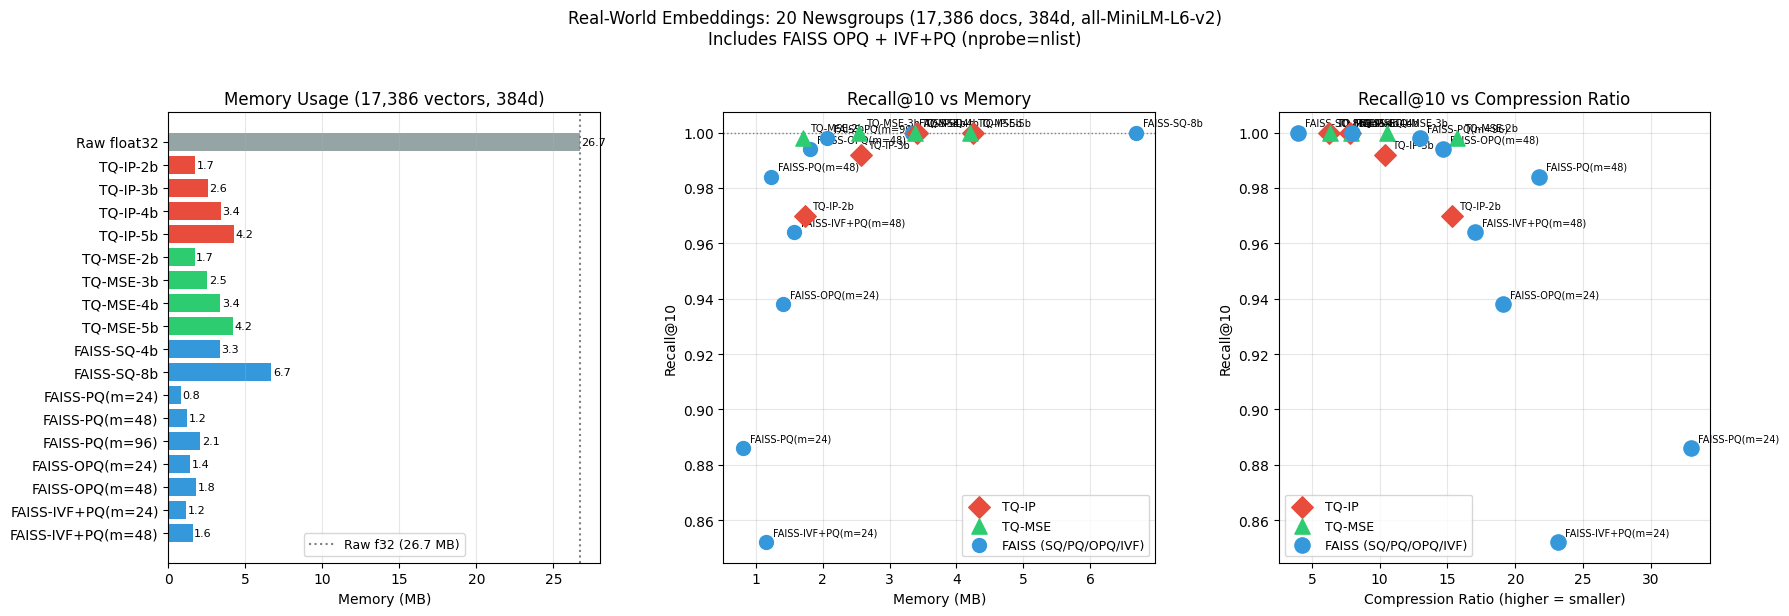

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ── Bar chart: memory usage ────────────────────────────────────────────────
ax = axes[0]
names = [r[0] for r in results]
mems  = [r[1] for r in results]
# Dynamic colors based on method prefix
color_map = {'Raw': '#95a5a6', 'TQ-IP': '#e74c3c', 'TQ-MSE': '#2ecc71', 'FAISS': '#3498db'}
colors = []
for n in names:
    for prefix, c in color_map.items():
        if n.startswith(prefix):
            colors.append(c)
            break
    else:
        colors.append('#9b59b6')

bars = ax.barh(names[::-1], mems[::-1], color=colors[::-1])
ax.set_xlabel('Memory (MB)')
ax.set_title(f'Memory Usage ({N_DB:,} vectors, {DIM}d)')
ax.axvline(x=raw_mb, color='gray', ls=':', lw=1.5, label=f'Raw f32 ({raw_mb:.1f} MB)')
ax.legend(fontsize=9)
ax.grid(alpha=0.3, axis='x')
for bar, mem in zip(bars, mems[::-1]):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{mem:.1f}', va='center', fontsize=8)

# ── Scatter: recall vs memory ──────────────────────────────────────────────
ax = axes[1]
tq_ip  = [r for r in results if r[0].startswith('TQ-IP')]
tq_mse = [r for r in results if r[0].startswith('TQ-MSE')]
faiss_r = [r for r in results if r[0].startswith('FAISS')]

ax.scatter([r[1] for r in tq_ip], [r[3] for r in tq_ip],
           s=120, marker='D', color='#e74c3c', zorder=5, label='TQ-IP')
ax.scatter([r[1] for r in tq_mse], [r[3] for r in tq_mse],
           s=120, marker='^', color='#2ecc71', zorder=5, label='TQ-MSE')
ax.scatter([r[1] for r in faiss_r], [r[3] for r in faiss_r],
           s=100, marker='o', color='#3498db', zorder=4, label='FAISS (SQ/PQ/OPQ/IVF)')
for r in results[1:]:
    ax.annotate(r[0], (r[1], r[3]), fontsize=7,
                textcoords='offset points', xytext=(5, 5))
ax.axhline(y=1.0, color='gray', ls=':', lw=1)
ax.set_xlabel('Memory (MB)')
ax.set_ylabel('Recall@10')
ax.set_title('Recall@10 vs Memory')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# ── Compression ratio vs recall ───────────────────────────────────────────
ax = axes[2]
for group, marker, color, label in [
    (tq_ip, 'D', '#e74c3c', 'TQ-IP'),
    (tq_mse, '^', '#2ecc71', 'TQ-MSE'),
    (faiss_r, 'o', '#3498db', 'FAISS (SQ/PQ/OPQ/IVF)'),
]:
    ratios = [raw_mb / r[1] for r in group]
    ax.scatter(ratios, [r[3] for r in group],
               s=120, marker=marker, color=color, zorder=5, label=label)
    for r in group:
        ax.annotate(r[0], (raw_mb / r[1], r[3]), fontsize=7,
                    textcoords='offset points', xytext=(5, 5))
ax.set_xlabel('Compression Ratio (higher = smaller)')
ax.set_ylabel('Recall@10')
ax.set_title('Recall@10 vs Compression Ratio')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.suptitle(f'Real-World Embeddings: 20 Newsgroups ({N_DB:,} docs, {DIM}d, all-MiniLM-L6-v2)\nIncludes FAISS OPQ + IVF+PQ (nprobe=nlist)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('real_world_memory.png', dpi=150, bbox_inches='tight')
plt.show()

## 5 · Semantic Search Demo

Search with a natural language query and verify that quantized results match exact search.

In [8]:
# Build indices at different compression levels
idx_4b = TurboQuantIndex(dim=DIM, bits=4, metric='ip', seed=SEED)
idx_4b.add(db_t)

idx_3b = TurboQuantIndex(dim=DIM, bits=3, metric='ip', seed=SEED)
idx_3b.add(db_t)

# Natural language queries
search_queries = [
    "What are the best strategies for space exploration?",
    "How does encryption work in computer security?",
    "What causes engine problems in cars?",
    "Is there evidence for God's existence?",
    "How do graphics cards work for gaming?",
]

q_emb = model.encode(search_queries, normalize_embeddings=True, convert_to_numpy=True)
q_emb_t = torch.from_numpy(q_emb)

# Exact search
exact_scores, exact_ids = flat.search(q_emb, 5)

# Quantized search
tq4_scores, tq4_ids = idx_4b.search(q_emb_t, k=5)
tq3_scores, tq3_ids = idx_3b.search(q_emb_t, k=5)

for i, query in enumerate(search_queries):
    print(f"\n{'='*80}")
    print(f"Query: {query}")
    print(f"{'='*80}")
    
    # Exact top-1
    eid = exact_ids[i, 0]
    print(f"\n  Exact top-1 (score={exact_scores[i,0]:.3f}):")
    print(f"    {texts[db_idx[eid]][:150]}...")
    
    # TQ-4b top-1
    tid4 = tq4_ids[i, 0].item()
    match4 = '✅' if tid4 == eid else '❌'
    print(f"\n  TQ-IP-4b top-1 {match4} (score={tq4_scores[i,0]:.3f}):")
    print(f"    {texts[db_idx[tid4]][:150]}...")
    
    # TQ-3b top-1
    tid3 = tq3_ids[i, 0].item()
    match3 = '✅' if tid3 == eid else '❌'
    print(f"\n  TQ-IP-3b top-1 {match3} (score={tq3_scores[i,0]:.3f}):")
    print(f"    {texts[db_idx[tid3]][:150]}...")


Query: What are the best strategies for space exploration?

  Exact top-1 (score=0.495):
    I might suggest giving the management some more mumble time by asking
the very leading question (in two or three parts)
   What are your long term exp...

  TQ-IP-4b top-1 ✅ (score=0.504):
    I might suggest giving the management some more mumble time by asking
the very leading question (in two or three parts)
   What are your long term exp...

  TQ-IP-3b top-1 ✅ (score=0.491):
    I might suggest giving the management some more mumble time by asking
the very leading question (in two or three parts)
   What are your long term exp...

Query: How does encryption work in computer security?

  Exact top-1 (score=0.482):
    Note:     The following was released by the White House today in
          conjunction with the announcement of the Clipper Chip
          encryption ...

  TQ-IP-4b top-1 ✅ (score=0.497):
    Note:     The following was released by the White House today in
          conjuncti

## 6 · Summary

In [9]:
print(f"\n{'='*65}")
print(f"  REAL-WORLD EMBEDDING COMPRESSION SUMMARY")
print(f"{'='*65}")
print(f"  Dataset     : 20 Newsgroups")
print(f"  Embedding   : all-MiniLM-L6-v2 ({DIM} dims)")
print(f"  Database    : {N_DB:,} documents")
print(f"  Queries     : {N_QUERIES} random held-out documents")
print(f"  Raw memory  : {raw_mb:.2f} MB")
print(f"  FAISS baselines include OPQ (learned rotation) + IVF+PQ (nprobe=nlist)")
print(f"{'='*65}")
print(f"{'Method':<22} {'Memory':>8} {'Savings':>9} {'R@1':>6} {'R@10':>6}")
print(f"{'-'*58}")
for name, mem, r1, r10, _, _, ratio in results:
    savings = f'{(1 - mem/raw_mb)*100:.0f}%' if mem < raw_mb else '  —'
    print(f"{name:<22} {mem:>7.2f}MB {savings:>9} {r1:>6.3f} {r10:>6.3f}")
print(f"{'='*65}")

# Highlight the sweet spot
best = [r for r in results if r[0] == 'TQ-IP-4b'][0]
best_opq = max([r for r in results if r[0].startswith('FAISS-OPQ')], key=lambda r: r[3])
print(f"\n TQ-IP-4b:")
print(f"   {raw_mb:.1f} MB -> {best[1]:.1f} MB ({(1-best[1]/raw_mb)*100:.0f}% smaller)")
print(f"   Recall@1={best[2]:.3f}, Recall@10={best[3]:.3f}")
print(f"   Zero training, single matrix multiply to compress")
print(f"\n Closest FAISS competitor — {best_opq[0]}:")
print(f"   {raw_mb:.1f} MB -> {best_opq[1]:.1f} MB ({(1-best_opq[1]/raw_mb)*100:.0f}% smaller)")
print(f"   Recall@1={best_opq[2]:.3f}, Recall@10={best_opq[3]:.3f}")
print(f"   Requires k-means training on data")


  REAL-WORLD EMBEDDING COMPRESSION SUMMARY
  Dataset     : 20 Newsgroups
  Embedding   : all-MiniLM-L6-v2 (384 dims)
  Database    : 17,386 documents
  Queries     : 500 random held-out documents
  Raw memory  : 26.70 MB
  FAISS baselines include OPQ (learned rotation) + IVF+PQ (nprobe=nlist)
Method                   Memory   Savings    R@1   R@10
----------------------------------------------------------
Raw float32              26.70MB         —  1.000  1.000
TQ-IP-2b                  1.74MB       93%  0.642  0.970
TQ-IP-3b                  2.57MB       90%  0.774  0.992
TQ-IP-4b                  3.41MB       87%  0.860  1.000
TQ-IP-5b                  4.24MB       84%  0.934  1.000
TQ-MSE-2b                 1.70MB       94%  0.770  0.998
TQ-MSE-3b                 2.54MB       90%  0.870  1.000
TQ-MSE-4b                 3.37MB       87%  0.912  1.000
TQ-MSE-5b                 4.21MB       84%  0.958  1.000
FAISS-SQ-4b               3.34MB       87%  0.888  1.000
FAISS-SQ-8b         